In [ ]:
# 데이터 로딩
import nibabel as nib

img = nib.load("/mnt/c/Users/lhe09/projects/msd_brain/imagesTr/BRATS_001.nii.gz")
data = img.get_fdata()

print(data.shape) # (240, 240, 155, 4)

# 240 * 240 - 이미지 크기
# 155 - depth(slice 수)
# 4 - MRI modality(flair, t1, t1ce, t2)

(240, 240, 155, 4)


In [ ]:
# PyTorch/3D 모델에서는 반드시 (4, H, W, D) 의 형태여야함.
# 채널 축을 앞으로 이동
import numpy as np

data = np.transpose(data, (3, 0, 1, 2))
print(data.shape) # (4, 240, 240, 155)

(4, 240, 240, 155)


In [ ]:
# label 확인
label = nib.load("/mnt/c/Users/lhe09/projects/msd_brain/labelsTr/BRATS_001.nii.gz").get_fdata()

print(label.shape) # (240, 240, 155)
print(np.unique(label)) # [0. 1. 2. 3.]

(240, 240, 155)
[0. 1. 2. 3.]


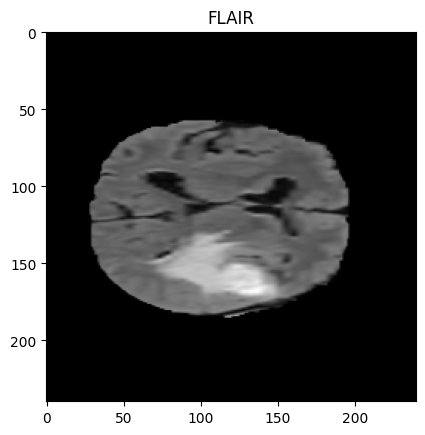

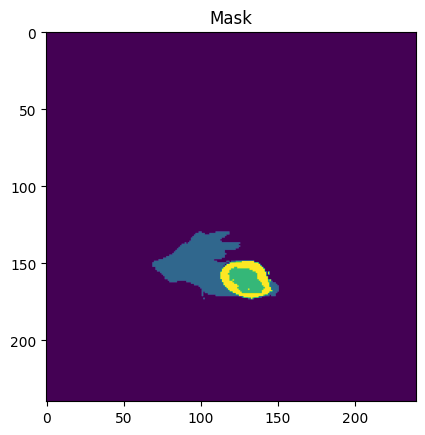

In [5]:
# slice 시각화
import matplotlib.pyplot as plt

slice_idx = 80

plt.imshow(data[0, :, :, slice_idx], cmap='gray')  # flair
plt.title("FLAIR")
plt.show()

plt.imshow(label[:, :, slice_idx])
plt.title("Mask")
plt.show()

In [8]:
# 데이터 리스트 만들기
import os

data_dir = "/mnt/c/Users/lhe09/projects/msd_brain"

images = sorted(os.listdir(os.path.join(data_dir, "imagesTr")))
labels = sorted(os.listdir(os.path.join(data_dir, "labelsTr")))

data_dicts = [
    {
        "image": os.path.join(data_dir, "imagesTr", img),
        "label": os.path.join(data_dir, "labelsTr", lbl),
    }
    for img, lbl in zip(images, labels)
]

print(data_dicts[0])

{'image': '/mnt/c/Users/lhe09/projects/msd_brain/imagesTr/BRATS_001.nii.gz', 'label': '/mnt/c/Users/lhe09/projects/msd_brain/labelsTr/BRATS_001.nii.gz'}


In [94]:
# 데이터 리스트 만드는데, 혹시 ._(보이면 안되는 파일이 있을까봐)
import os

data_dir = "/mnt/c/Users/lhe09/projects/msd_brain"

images = sorted([
    f for f in os.listdir(os.path.join(data_dir, "imagesTr"))
    if not f.startswith("._")
])

labels = sorted([
    f for f in os.listdir(os.path.join(data_dir, "labelsTr"))
    if not f.startswith("._")
])

print(images[:3])
print(labels[:3])

['BRATS_001.nii.gz', 'BRATS_002.nii.gz', 'BRATS_003.nii.gz']
['BRATS_001.nii.gz', 'BRATS_002.nii.gz', 'BRATS_003.nii.gz']


In [6]:
# 매칭 확인
for i in range(5):
    print(images[i], labels[i])

BRATS_001.nii.gz BRATS_001.nii.gz
BRATS_002.nii.gz BRATS_002.nii.gz
BRATS_003.nii.gz BRATS_003.nii.gz
BRATS_004.nii.gz BRATS_004.nii.gz
BRATS_005.nii.gz BRATS_005.nii.gz


In [97]:
# 데이터 리스트 만드는데, 혹시 ._(보이면 안되는 파일이 있을까봐)
import os

data_dir = "/mnt/c/Users/lhe09/projects/msd_brain"

images = sorted([
    f for f in os.listdir(os.path.join(data_dir, "imagesTr"))
    if not f.startswith("._")
])

labels = sorted([
    f for f in os.listdir(os.path.join(data_dir, "labelsTr"))
    if not f.startswith("._")
])


# 이름 기준으로 매칭
data_dicts = []

for img in images:
    label = img  # 이름 동일
    data_dicts.append({
        "image": os.path.join(data_dir, "imagesTr", img),
        "label": os.path.join(data_dir, "labelsTr", label),
    })

In [98]:
# MONAI Transform
import torch
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    ScaleIntensityd,
    RandCropByPosNegLabeld,
    CenterSpatialCropd,
    #RandSpatialCropd,
    EnsureTyped,
)

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    
    ScaleIntensityd(keys="image"),
    
    #RandSpatialCropd( # 데이터 한개로 overfitting 해봤는데, loss가 안 줄음. 학습이 안되서 centerspatialcropd로 바꿈
    #    keys=["image", "label"],
    #    roi_size=(128, 128, 128),
    #    random_size=False
    #),
    #CenterSpatialCropd( #loss가 희미하게 줄음. 여전히 잘 못배우고 있어서 RandCropbyPosneglabeld로 수정, 램덤 고정하기 위해 다시 
    #    keys=["image", "label"],
    #    roi_size=(64,64,64)
    #),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(64,64,64), # 128이 너무 커서 overfitting 시키기 위해 줄임
        pos=1,
        neg=1,
        num_samples=1
    ),

    EnsureTyped(
        keys=["image"], 
        dtype=torch.float32
    ),
    EnsureTyped(
        keys=["label"],
        dtype=torch.long
    )
])

# Dataset & DataLoader
from monai.data import Dataset, DataLoader

train_ds = Dataset(data=data_dicts[:60], transform=train_transforms)

train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=False,
    num_workers=2,
)

In [99]:
# 3D UNet 모델
import torch
from monai.networks.nets import UNet
from monai.losses import DiceCELoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    channels=(16, 32, 64),
    strides=(2, 2, 2),
)

model = model.to(device)

# Loss + Optimizer
from monai.losses import DiceLoss

#loss_function = DiceLoss(to_onehot_y=True, softmax=True)
loss_function = DiceCELoss(to_onehot_y=True, softmax=True, lambda_dice=1.0, lambda_ce=1.0, squared_pred=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [67]:
# Training loop
for epoch in range(3):
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        #labels = labels.long() # [0., 1., 2., 3.] -> [0, 1, 2, 3]
    
        optimizer.zero_grad()
        outputs = model(images)

        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {epoch_loss:.4f}")

Epoch 0, Loss: 2.1529
Epoch 1, Loss: 2.0598
Epoch 2, Loss: 1.9947


In [68]:
# label값/ 채널수/ loss 설정 중 하나가 틀려서 터짐을 확인함.
for batch in train_loader:
    labels = batch["label"]   # 아직 .to(device) 하지마(한번 터져서...)
    images = batch["image"]
    #labels= labels.long()
    #labels = labels.squeeze(1)

    print(labels.shape)
    print(labels.min(), labels.max())
    print(torch.unique(labels))
    print(labels.dtype)
    print(images.shape)
    print(outputs.shape)

    break  # 한 번만 확인

#torch.Size([1, 1, 128, 128, 128]) # labels.squeeze(1)로 [1, 1, 128, 128, 128] -> [1, 128, 128, 128]로 변환
#metatensor(0.) metatensor(3.)
#metatensor([0., 1., 2., 3.]) # 라벨이 float임.. labels.long()으로 해야함.
#torch.float32 # torch.int64가 정상인데.. label이 float라서 DiceLoss에서 터짐 label -> onehot 변환할때 정수여야 하는데 float이라서
# 결론은 float label + onehot + class mismatch로 CUDA 터짐.

torch.Size([1, 1, 64, 64, 64])
metatensor(0) metatensor(3)
metatensor([0, 1, 2, 3])
torch.int64
torch.Size([1, 4, 64, 64, 64])
torch.Size([1, 4, 64, 64, 64])


In [100]:
# overfitting test
#train_ds = Dataset(data=data_dicts[:1], transform=train_transforms)
# Training loop
for epoch in range(100):
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        #labels = labels.long() # [0., 1., 2., 3.] -> [0, 1, 2, 3] -> transformer 에서 정의함으로 변경
    
        optimizer.zero_grad()
        outputs = model(images)

        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {epoch_loss:.4f}")
    # 1️⃣ optimizer param 개수
    #print(len(optimizer.param_groups[0]["params"]))
    #for name, param in model.named_parameters():
    #    print(param.abs().mean())
    #    print(name, param.requires_grad)
    #    break
    # 3️⃣ device 확인
    #for param in model.parameters():
    #    print(param.device)
    #    break

Epoch 0, Loss: 94.1589
Epoch 1, Loss: 71.6621
Epoch 2, Loss: 68.1200
Epoch 3, Loss: 58.7897
Epoch 4, Loss: 57.7216
Epoch 5, Loss: 53.9758
Epoch 6, Loss: 56.3854
Epoch 7, Loss: 52.8058
Epoch 8, Loss: 50.7710
Epoch 9, Loss: 51.1309
Epoch 10, Loss: 48.6307
Epoch 11, Loss: 50.2596
Epoch 12, Loss: 45.7337
Epoch 13, Loss: 49.2593
Epoch 14, Loss: 50.3332
Epoch 15, Loss: 47.4822
Epoch 16, Loss: 51.1136
Epoch 17, Loss: 44.9137
Epoch 18, Loss: 42.4112
Epoch 19, Loss: 44.5550
Epoch 20, Loss: 48.5757
Epoch 21, Loss: 45.3100
Epoch 22, Loss: 46.4621
Epoch 23, Loss: 50.9755
Epoch 24, Loss: 43.8321
Epoch 25, Loss: 47.2448
Epoch 26, Loss: 44.5950
Epoch 27, Loss: 48.8980
Epoch 28, Loss: 43.3916
Epoch 29, Loss: 44.5800
Epoch 30, Loss: 45.9914
Epoch 31, Loss: 48.7572
Epoch 32, Loss: 41.1876
Epoch 33, Loss: 43.7931
Epoch 34, Loss: 45.4042
Epoch 35, Loss: 43.9260
Epoch 36, Loss: 43.8263
Epoch 37, Loss: 43.2929
Epoch 38, Loss: 43.2814
Epoch 39, Loss: 42.4452
Epoch 40, Loss: 48.3281
Epoch 41, Loss: 42.9214
Ep

In [ ]:
# overfitting test 결과 (1개의 데이터로 학습)
# overfitting 실패 상태라서
# 1. RandspatialCropd -> CenterSpatialCropd로 변경 # 그래도 학습이 안되서
# 2. DiceLoss -> DiceCELoss, CenterSpatialCropd -> RandCropByPosNegLabeld로 변경, lr 1e-4 -> 1e-3으로 변경
# loss가 확실히 줄긴하지만 overfitting 정도는 아니라 
# 3. num_samples 1->4, epoch 20 -> 50으로 변경 # 여전히 학습은 되지만 데이터 1개로 아직도 overfitting이 안됨
# 4. epoch 50 -> 100, channels (16, 32, 64, 128)->(32, 64, 128, 256), num_sample 4->8로 변경
# overfitting은 아니지만 loss가 확실하게 줄어서 학습과 성능이 좋은 것을 확인 

In [ ]:
# Validation
import os

data_dir = "/mnt/c/Users/lhe09/projects/msd_brain"

images = sorted([
    f for f in os.listdir(os.path.join(data_dir, "imagesTr"))
    if not f.startswith("._")
])

labels = sorted([
    f for f in os.listdir(os.path.join(data_dir, "labelsTr"))
    if not f.startswith("._")
])

# 이름 기준으로 매칭
data_dicts = []

for img in images:
    label = img  # 이름 동일
    data_dicts.append({
        "image": os.path.join(data_dir, "imagesTr", img),
        "label": os.path.join(data_dir, "labelsTr", label),
    })



In [101]:
# Validation split
train_files = data_dicts[:60]
val_files = data_dicts[60:80]

In [102]:
# val_transform
import torch
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd, EnsureTyped, RandCropByPosNegLabeld, CenterSpatialCropd

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityd(keys="image"),

    #CenterSpatialCropd( 
    #    keys=["image", "label"],
    #    roi_size=(64,64,64)
    #),

    RandCropByPosNegLabeld(   # 🔥 train과 동일하게
        keys=["image", "label"],
        label_key="label",
        spatial_size=(64,64,64),
        pos=1,
        neg=1,
        num_samples=1
    ),

    EnsureTyped(keys=["image"], dtype=torch.float32),
    EnsureTyped(keys=["label"], dtype=torch.long),

])

In [103]:
# dataLoader
val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1)

In [104]:
# Dice Metirc 설정
from monai.metrics import DiceMetric
from monai.transforms import Activations, AsDiscrete
from monai.inferers import sliding_window_inference

dice_metric = DiceMetric(
    include_background=False,  # 🔥 background 제외
    reduction="mean_batch"
)

post_pred = Compose([
    Activations(softmax=True),
    AsDiscrete(argmax=True)
    #AsDiscrete(argmax=True, to_onehot=4) # onehot 처리가 잘 안됨, MONAI MetaTensor + batch 처리 때문에 깨짐
])

post_label = Compose([
    AsDiscrete(to_onehot=4)
])

In [105]:
# validation Loop
model.eval()
dice_metric.reset()

with torch.no_grad():
    for val_batch in val_loader:
        val_images = val_batch["image"].to(device)
        val_labels = val_batch["label"].to(device)

        # 🔥 3D 전체 inference (sliding window)
        val_outputs = sliding_window_inference(
            val_images,
            roi_size=(64,64,64),
            sw_batch_size=1,
            predictor=model
        )

        #probs = torch.softmax(val_outputs, dim=1) # max prob: metatensor(0.2500, device='cuda:0')
        #print("max prob:", probs.max()) 

        # post_pred에서 onehot빼고 직접 시킴
        # 🔥 pred 처리
        val_outputs = torch.argmax(val_outputs, dim=1)
        val_outputs = torch.nn.functional.one_hot(val_outputs, num_classes=4)
        val_outputs = val_outputs.permute(0, 4, 1, 2, 3).float()

        # 🔥 label 처리
        val_labels = val_labels.long()
        # pred[4, 4, 240, 240, 155], label[4, 1, 240, 240, 155]으로 달라서 맞춰줌
        val_labels = val_labels.squeeze(1)
        val_labels = torch.nn.functional.one_hot(val_labels, num_classes=4)
        val_labels = val_labels.permute(0, 4, 1, 2, 3).float()

        #print("pred shape:", val_outputs.shape)
        #print("label shape:", val_labels.shape)

        #print(val_outputs.sum()) # metatensor(35712000., device='cuda:0')
        #print(val_labels.sum()) # metatensor(8928000., device='cuda:0') # onehot이 제대로 되지 않음.

        #print("pred unique:", torch.unique(val_outputs))
        #print("label unique:", torch.unique(val_labels))
        print(torch.unique(torch.argmax(val_outputs, dim=1))) # metatensor([0], device='cuda:0')

        dice_metric(y_pred=val_outputs, y=val_labels)

dice_score = dice_metric.aggregate()

print("Dice per class:", dice_score)
print("Validation Dice:", dice_score.mean().item()) # 평균

dice_metric.reset()

metatensor([0, 1, 3], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0, 1, 2], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0, 1, 3], device='cuda:0')
metatensor([0, 1], device='cuda:0')
metatensor([0, 1, 3], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0, 1, 3], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
metatensor([0, 1, 2, 3], device='cuda:0')
Dice per class: tensor([0.4432, 0.3317, 0.3297], device='cuda:0')
Validation Dice: 0.36818426847457886


In [ ]:
# Validation Dice : 0.0인데, 시각화에서는 tumor를 잡음...
# 계산 문제 인것 같아서, post_pred에 to_onehot=4 추가함.
# 그리고 채널 수가 달라서 Dice 계산이 안되는 거였음.
#pred shape: torch.Size([4, 4, 240, 240, 155])
#label shape: torch.Size([4, 1, 240, 240, 155])
#pred unique: metatensor([0., 1.], device='cuda:0')
#label unique: metatensor([0., 1.], device='cuda:0')
# 수정했는데, 1.9917이렇게 나옴... 이러면 안됨
# class별로 Dice합쳐서 나온 것 같음. diceMetric의 reduction "mean"->"mean_batch"로 변경
# 그래서 안되서, val_outputs이랑 albels sum()을 보니 onehot이 안되고 다 1,1,1,1로 되어 4배로 나오는 것으로 보아 post_pred를 버리고 직접처리로 바꿈
# 그리고 class가 [0, 1, 2, 4] -> [0, 1, 2, 3]으로 바꿈

# dice_score 해석
#0.0 ~ 0.3 -> 거의 못 맞춤
#0.3 ~ 0.5 -> 기본 수준
#0.6 ~ 0.8 -> 꽤 잘함
#0.8+      -> 매우 잘함

In [77]:
# Inference(단일 케이스)
model.eval()

sample = val_ds[0]

image = sample["image"].unsqueeze(0).to(device)
label = sample["label"]

with torch.no_grad():
    output = sliding_window_inference(
        image,
        roi_size=(64,64,64),
        sw_batch_size=1,
        predictor=model
    )

output = torch.argmax(output, dim=1).cpu().numpy()[0]
label = label.numpy()[0]

IndexError: index 80 is out of bounds for axis 4 with size 64

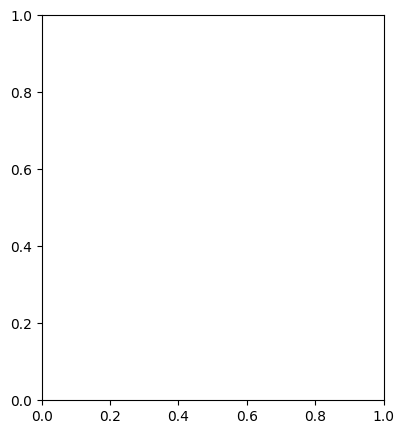

In [78]:
# 시각화
import matplotlib.pyplot as plt

slice_idx = 80

plt.figure(figsize=(15,5))

# 원본 이미지 (flair)
plt.subplot(1,3,1)
plt.imshow(image.cpu().numpy()[0,0,:,:,slice_idx], cmap='gray')
plt.title("Image")

# GT
plt.subplot(1,3,2)
plt.imshow(label[:,:,slice_idx])
plt.title("Ground Truth")

# Prediction
plt.subplot(1,3,3)
plt.imshow(output[:,:,slice_idx])
plt.title("Prediction")

plt.show()

In [ ]:
# train[:60]
# validation[60:80]

# UNet
# Epoch 33, loss: 15.2945, Dice: 0.5393

# attentionUNet
# Epoch 84, loss: 12.5106, Dice: 0.5340

# DynUNet
# Epoch 94,loss: 12.2563, Dice: 0.5595

# 성능 강화보다. 시각화를 해보기!
# 왜냐하면 Dice는 평균값이니깐 원인을 알 수 없어. 시각화로 문제 원인 알아보기
# case1 : 위치는 맞는데 흐림 -> epoch 증가, loss 조정
# case2 : 일부 class만 안되 -> class imblance 해결, DiceFocalLoss
# case3 : 완전 엉뚱 -> 데이터/tranform문제, label misatch
# case4 : tumor 거의 없음 -> sampling 문제, RandCropByPosNegLabeld 강화

In [ ]:
# 따라서 inference(추론).py로 확인하기!
# pred unique
# label unique 
# 두개 꼭 확인하기

# 이미지에서는
# 위치, tumor 크기, 특정 class가 없는거 확인하기

In [ ]:
# 시각화 업그레이드
# 1. 3D volumetric visualization(marching cube, interactive viewer)
# 2. class별 색깔 overlay
# 3. GIF 만들기(slice animation)

In [ ]:
👉 inference.py
best_model 로드
3D 결과 저장 (.nii)
👉 visualize.ipynb
slice별 tumor overlay
GT vs prediction 비교

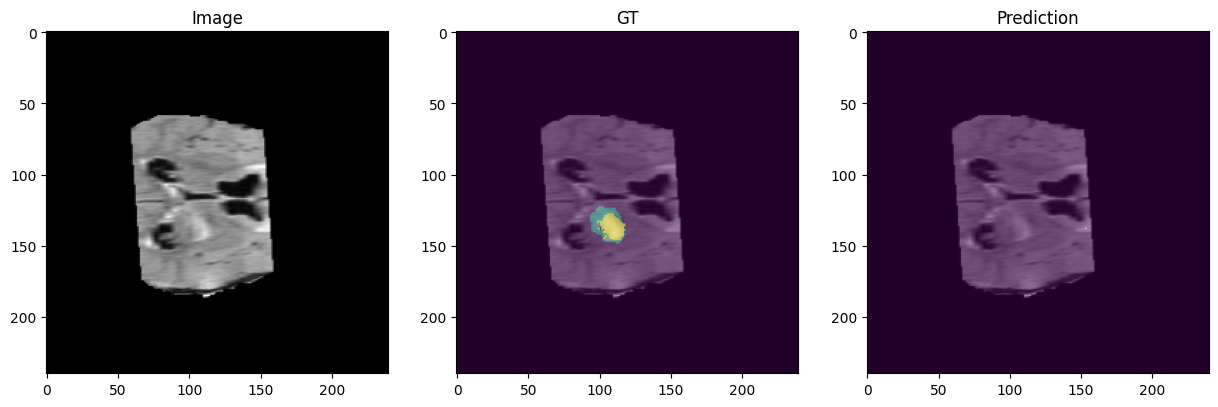

In [6]:
# inference.py 후에 
# visualize
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

pred = nib.load("../outputs/preds_swin/BRATS_021_pred.nii.gz").get_fdata()

# GT도 같이 보고 싶으면
label = nib.load("/mnt/c/Users/lhe09/projects/msd_brain/labelsTr/BRATS_021.nii.gz").get_fdata()
image = nib.load("/mnt/c/Users/lhe09/projects/msd_brain/imagesTr/BRATS_021.nii.gz").get_fdata()

# slice 시각화
slice_idx = 80

plt.figure(figsize=(15,5))

# image
plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image[:,:,slice_idx,0], cmap="gray")

# GT
plt.subplot(1,3,2)
plt.title("GT")
plt.imshow(image[:,:,slice_idx,0], cmap="gray")
plt.imshow(label[:,:,slice_idx], alpha=0.5)

# pred
plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(image[:,:,slice_idx,0], cmap="gray")
plt.imshow(pred[:,:,slice_idx], alpha=0.5)
# class 색깔 다르게
#plt.imshow(pred[:,:,slice_idx], cmap="jet", alpha=0.5)

plt.show()


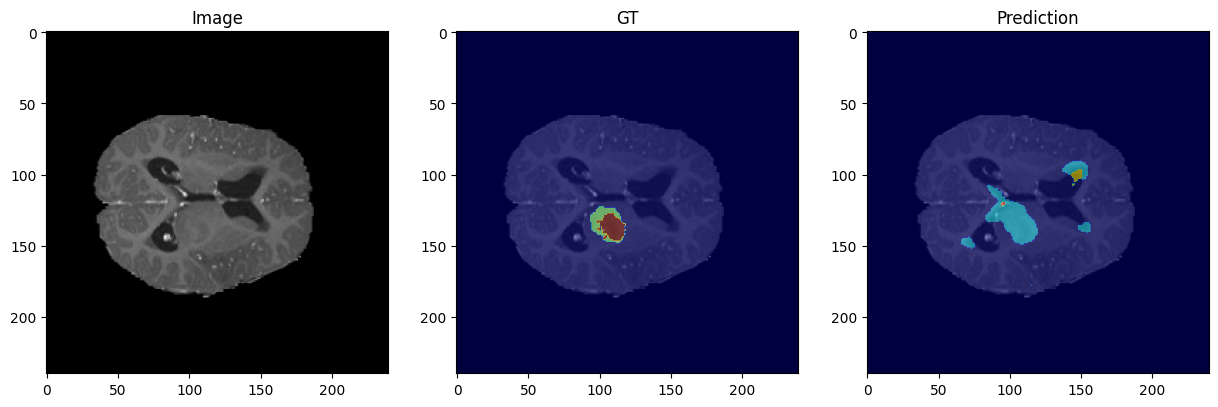

[0. 1. 2. 3.]
3.0 0.0


In [9]:
# inference.py 후에 
# visualize
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

pred = nib.load("../outputs/preds_dyn1/BRATS_021_pred.nii.gz").get_fdata()

# GT도 같이 보고 싶으면
label = nib.load("/mnt/c/Users/lhe09/projects/msd_brain/labelsTr/BRATS_021.nii.gz").get_fdata()
image = nib.load("/mnt/c/Users/lhe09/projects/msd_brain/imagesTr/BRATS_021.nii.gz").get_fdata()

# slice 시각화
slice_idx = 80

plt.figure(figsize=(15,5))
# image
plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image[:,:,slice_idx,2], cmap="gray")  # ⭐ t1ce 추천

# GT
plt.subplot(1,3,2)
plt.title("GT")
plt.imshow(image[:,:,slice_idx,2], cmap="gray")
plt.imshow(label[:,:,slice_idx], cmap="jet", alpha=0.5)

# pred
plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(image[:,:,slice_idx,2], cmap="gray")
plt.imshow(pred[:,:,slice_idx], cmap="jet", alpha=0.5)

plt.show()
print(np.unique(pred))
print(pred.max(), pred.min())

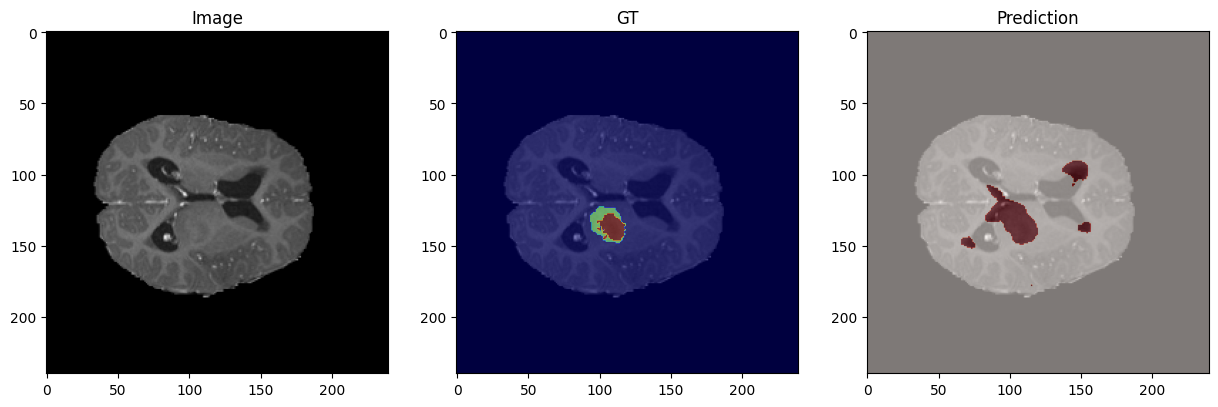

In [11]:
slice_idx = slice_idx

plt.figure(figsize=(15,5))

# image
plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image[:,:,slice_idx,2], cmap="gray")

# GT
plt.subplot(1,3,2)
plt.title("GT")
plt.imshow(image[:,:,slice_idx,2], cmap="gray")
plt.imshow(label[:,:,slice_idx], cmap="jet", alpha=0.5)

# Pred (전체 tumor)
plt.subplot(1,3,3)
plt.title("Prediction")

tumor_mask = pred[:,:,slice_idx] > 0

plt.imshow(image[:,:,slice_idx,2], cmap="gray")
plt.imshow(tumor_mask, cmap="Reds", alpha=0.5)

plt.show()

In [ ]:
## 시각화 이후
# UNet은 [0. 1. 2. 3.]이 나오지만 GT랑 겹치지 않음(위치가 틀림)(overlap은 117이고 tumor 탐지는 7781)
# AttentiionUNet은 [0]만 있음(background collapse) (overlap은 0이고 tumor 탐지도 0)
# DynUnet은 [0. 1. 2. 3.]이 나오지만 brain 전체에 뿌림(overlap은 49628 tumor 탐지는 1028874)
# (탐지해야하는 GT tumor 수는 49639개임)

# 모든 모델이 제대로 학습하고 있지 못함.(클래스 종류는 배웠는데, 위치는 배우지 못함)
# 원인으로는 tumor가 너무 작고, gackground가 압도적이며, sampling이 잘못된 것 같음. 거의 암이 없는 구간만 배우고 있음
# 따라서, roi_size 64->128로 키우기, num_samples 2->4 늘리기
# UNet epoch 61, loss 9.9605, Dice:0.5806
# 시각화로 보니 tumor를 찾는데, dynunet처럼 과하게 ground를 예측함. -> sampling은 해결(tumor를 봄), 여전히 imbalance(다tumor로)
# DiceFocalLoss를 DiceCELoss로 바꾸기 Dice는 영역맞춤이고, CE는 class 구분 강화로 class 구분이 약해서 조절해야함
# 그리고 과하게 tumor로 인식하니 pos 2->1로 다시 줄여보기
# Epoch 32, Loss: 8.7579, Dice: 0.5663

# DiceCELoss의 dice, ce 숫자를 서로 바꿔 입력, batch 2->4(train), 1->2(val), 데이터수를 60-> 80(train), lr 0.001->0.0005로 수정
# Epoch: 115, Loss: 1.9420, Dice: 0.6838
# "전체 3D 이미지"를 보고 싶은데 한번 GPU 터지니깐 sliding_window_inference 사용(이미지를 잘게 쪼개서 하나씩 예측, 다시 붙임)
# sliding_window_inference은 overlap을 추가함(경계가 끊겨서 Dice이 떨어지지 않도록 추가함)
# Dice: 0.6이면 학습은 잘 되는 편 하지만, 이상하게 나옴. 그래서 무조건 하나 선택하는, argmax 대신 애매한 확률인 softmamx와 threshold, noise 제거를 위한 post-precessing 
# Scheduler 수정(CosineAnnealing->ReduceLROnPlateau), sliding_window_inference를 TTA로 수정, argmax를 softmax와 threshold로 수정, connected component 추가
# connectd component는 작은점 nosie 많을때, tumor는 맞는데 주변에 잡음이 있을 때, 많이 사용.
# prob는 0.9이상을 찍는데, prob tumor를 0.25미만으로 나와, 거의 백그라운드로 확실함. 그래서 pos를 높이고 threshold를 낮추고 class_weight를 높임.
# loss: 2.5208, Dice: 0.2121 더 낮아짐.
# CE weight과 비율을 너무 높여 모델이 배경 vs tumor의 균형을 잃어버림.학습을 망쳐버림 theshold랑 weight을 되돌림,TTA도 제외함
# softmax와 threshold도 없앰,connected component없앰
# 원래대로 돌리니 epoch: 205, Loss: 2.5223, Dice: 0.6565

# class_weight만 추가 Epoch 187, Loss: 2.9270, Dice: 0.6579

# TTA로 바꿔봄 Epoch 153, Loss: 2.8435, Dice: 0.6666
# pos=3->4로 올리고, roi_size 128->96으로 줄이고, ce_weight=약간 증가, dice높임
# Dice에서 
# lambda_dice loss는 전체겹침(overlap), 구조/위치 맞추기, class imbalance에 강함(대충 어디에 있는지 맞추는 능력)
# lambda_ce(cross entropy)는 픽셀 단위 분류, 경계, 디텔일, class 구분 정확도(정확히 무슨 클래스인지 맞추는 능력)
# 따라서 나는 지금 tumor를 못찾고 있어서, dice을 높여야함. (tumor를 못 잡으면 dice높이고, tumor 잡는데 지저분하면 CE를 높이고)
# 주의점은 CE가 많으면 성능이 좋은건 아님(CE는 background에 끌려, tumor를 무시하게 됨.)
# 픽셀 단위로 하는 CE가 높아지면 클래스 불균형에 의해 background를 선택하는것이 이득이라고 생각하기 때문에 tumor를 찾기위해서는 CE를 높이는게 답은 아님

# Epoch 192, Loss: 4.9910, Dice: 0.6776
# CE_Weight조금 낮춤, roi_size 96->64로 더 낮춰보기 background가 더 낮아져서 학습이 잘 될 수도 있음.(tumor가 더 잘 보여서)

# Epoch 123, Loss: 6.9026, Dice: 0.6219, roi_size 다시 96으로 높이고, CE Weight높임,
# Epoch 192, Loss: 4.9949, Dice: 0.6775

# 더이상 세부 조정보다 다른 모델로 가는게 좋을 것 같다고 판단함
# 1. DynUNet - patch 기반 최적화, deep surpervision, MSD benchmark강자
# 2. SwinUNETR - Transformer 기반, global context 이해, 작은 tumor 잘 잡음
# 3. UNERT - tansformer + UNet, SwinUNERT 보다 약간 구형
# 4. nnUNet - 자동 최적화, 의료 segmentation SOTA(구조이해가 어려움, 커스터마이징이 힘듦)
# 따라서, SwinUNTR, DynUNet, nnUNet 해보기
# SwinUNETR batchsize는 4->1로 줄려서 시작 100에서 강제 멈춤, Loss: 20.6906, Dice: 0.6921
# 시각화에서 segmentation이 안나타남. SwinUNTR은 확률기반이라 softmax 필수, 없으면 망함.
# validation에서 20개를 5개로 줄이고, pos 4->6으로 늘리고 다시 training시작

In [ ]:
# SwinUNTR 를 했는데, Dice=0.69이 나오는데, 시각화에서는 tumor각 잡히지 않음
# dynunet에서는 시각화로 tumor가 보이는데, SwinUNETR은 안보이는 이유는 
## Dynunet(local: CNN)은 작은 패턴을 잘잡고, tumor detection에 강하지만 global context는 약함
## SwinUNETR(gloval: Transformer)은 전체 구조 이해를 잘하고, context 기반 판단이지만 작은 tumor는 무시 가능
# 3D로 학습했는데, 2D인 슬라이스를 잘못 잡는 것 같아서 tumor slice를 찾으려고 함

In [7]:
# tumor 있는 slice 찾기와 시각화

# tumor 있는 slice 찾기
tumor_slices = []

for i in range(pred.shape[2]):
    if np.sum(pred[:, :, i] > 0) > 20:  # threshold는 10~50 사이 추천
        tumor_slices.append(i)

print("Tumor slices:", tumor_slices[:10])  # 일부만 출력

Tumor slices: [2, 3, 4, 42, 43, 44, 60, 61, 62, 63]


In [8]:
# tumor 가장 큰 slice찾기
slice_sizes = [np.sum(pred[:, :, i] > 0) for i in range(pred.shape[2])]
slice_idx = np.argmax(slice_sizes)

print("Best slice:", slice_idx)

Best slice: 3


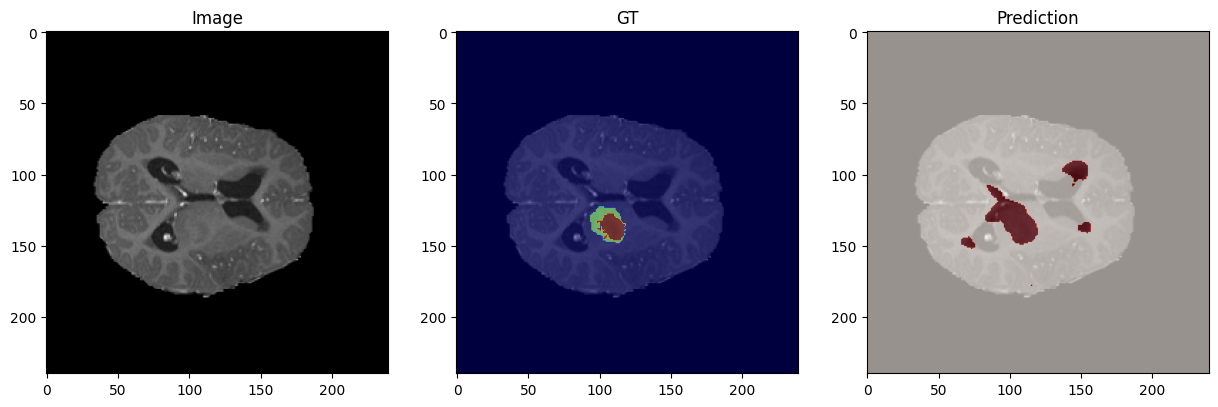

In [2]:
plt.figure(figsize=(15,5))

# image
plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image[:,:,slice_idx,2], cmap="gray")  # t1ce 추천

# GT
plt.subplot(1,3,2)
plt.title("GT")
plt.imshow(image[:,:,slice_idx,2], cmap="gray")
plt.imshow(label[:,:,slice_idx], cmap="jet", alpha=0.5)

# pred (tumor만 강조)
plt.subplot(1,3,3)
plt.title("Prediction")

tumor_mask = pred[:,:,slice_idx] > 0

plt.imshow(image[:,:,slice_idx,2], cmap="gray")
plt.imshow(tumor_mask, cmap="Reds", alpha=0.6)

plt.show()

In [ ]:
# 지금 SwinUNETR은 약한 확인으로 Threshold로 보니깐 argmax에서 보이지 않았던, 경계/ 구조, 헷갈려 하는 영역이 보임
# SwinUNETR은 확신 없으면 argmax에서 버리지만 prob 자체는 남아 있어서 숨어있던 의심 영역이 나타남
# 그래서 CE Weight[0.5, 1.2]->[0.3,1.5]는 조금더 높이고, connected component해보기(작은 점들 제거하고 진짜 tumor만 남김게)
#  Loss: 27.6457, Dice: 0.6862 여전히 tumor를 못찾음
# SwinUNETR은 sliding_window를 써야한다고 함. 3D 이미지를 나눠서 예측후 합치는 방식이 SwinUNETR랑 기본 전제라 안쓰면 깨짐
# 따라서, sliding_window추가하고, TTA를 없앰 lr도 0.0001에서 0.0005로 올림
#  Loss: 30.7332, Dice: 0.6857 여전히 tumor를 못찾고, [0. 1. 2.] 만 나옴
# SwinUNERT은 Transformer 기반인데, 데이터 80개로 하려고 하니깐 잘 맞지 않는 것 같음(데이터를 늘리기에는 시간이 너무 오래걸림)
# 다시 dynUNet(CNN 기반, 데이터 적어도 괜찮음)으로 하고, nnUNET(데이터 적어도 알아서 최적화해줌)해보기

# 그럼 UNet과 AttentionUNet과 CNN기반인데 왜 안나오나? 확인해보니,(pred.min/max값 확인, 클래스(unique)값 확인)
# DynUNet만 제대로 학습이 됨(4클래스 모두)이유는 deep supervision이고 receptive field에 좋고, MONAI에 최적화되어 small class모두가 다 살아남음
# UNet은(class 2가 죽음) 중간 크기 tumor를 못잡음
# SwinUNERT은(class 3이 죽음) 작은 영역은 완절이 무시됨 tranformer 기반에 작은 데이터양 때문에 데이터가 부족 학습부족
# Attention은(max가 0이고 아무 클래스도 잡지못함) 학습이 완전 망가짐
# 그럼 왜 Dice는 비슷한 0.69나왔나? 모든 클래스 값의 평균이기 때문에

## 따라서, DynUNet의 학습을 해보고, 그 기반으로 다시 UNet과 Attention을 해보고 nnUNET으로 가보기
# 그리고 per class Dice[클래스별 Dice을 보는 것]과 Hausdorff Distance(HD95)[실제 boundary와 예측 boundary 같의 최대 거리] 같이 보기

# 새로 학습한 DynUNet Dice=0.70가 나왔는데  -------(dynunet1.pth/preds_dyn1)
#===== FINAL AVERAGE =====
#Dice mean: [[0.952364   0.02493604 0.18261637 0.35108438]]
#HD95 mean: [[57.939625 59.338017 63.89053 ]] 라서 CE_weight를 수정하려고 함 [0.3, 1.5, 1.5, 1.5] -> [0.1, 3.0, 3.0, 3.0]
# argmentation 추가, normalization(mean사용) 대신 ScaleIntensityRanged(min/max 사용), CC(connected component)끔
# class1에 Weight를 많이 주지 않는 이유는 클래스1인 edema가 가장 펴져 있고, 애매한 구조의 특징 때문, 경계가 흐리고, intensity overlap이 많음
# 그래서 class 1은 다양성이 없으면 배우기 어려움(argmentation이 필요)
# 학습을 했는데 loss가 110이상 나와 붕괴가 일어나서, argmentation에서 2개 빼고 다 없애고, CE_weight[0.1, 1.0]으로 줄이고, pos 4->2로 줄임, lr 0.0005->0.0001
# loss: 70 미만, Dice: 0.16임.. 그래서 batch 1->4, CE_weight [0.1, 1.5]->[0.1,2.0]

# 만일 클래스가 계속 무너진다면, RandCropByPosNegLabeld 대신 RandCropByLabelClassesd이거 써보기(클래스별 patch를 따로 뽑음)
# class 3번이 계속 crop에 없다고 warning이 떠서, num_sample4->6으로 증가 그래도 labelclassesd의 class3가 0이라고 뜸.
# class 3번이 crop되지 않아서 못 배우는 것보다, posneg에서 3번이 포함되었을때 학습이 되게 하는것이 낫다고 생각

# 그래서 posneg가로 다시 가고, class 3의 weight를 높이기로 함 loss가 27정도, dice 0.123까지 올라옴
# pos 6->8로 올리고, lr 0.0001->0.00005로 낮춤 계속 0.1로 Dice이 나타남
# ScaleIntensityRanged(min/max 사용)[이건 CT 기준이라서 MRI에는 안됨] -> nomalized로 수정함, softmax 추가

# Loss: 12.6630, Dice: 0.6704 Dice이 0.67로 잘나옴. 그리고 시각화에서도 잘 잡음. 하지만, GT보다 더 넓게 잡힘(false positive), 경계가 흐림
# 그리고 class별은 calss1이 조금 덜 나옴 Dice mean: [[0.9983865  0.32140505 0.7162235  0.8613927 ]] 
# 그래서 [0.2, 2.0, 2.0, 3.0]->[0.2, 2.5, 2.0, 2.5]로 수정하고, RandShiftIntensityd 추가, post-processing(작은 false positive 제거)와 TTA 추가
# 이번 학습된 모델의 checkpoint로 위 변경사항을 가지고 학습하려고 함

# 전체 Dice는 0.6690으로 나왔지만 class 1의 dice이 조금 늘었고 (Dice mean: [[0.99835384 0.3164494  0.71868813 0.85177034]]), 시각화에서 다른 곳을 찍던 것도 줄었음
# class 1의 weight을 조금 늘림 [0.2, 2.5, 2.0, 2.5]->[0.2, 3.0, 2.0, 2.0]

# Dice이 오르지 않는 이유는 checkpoint로 connected component를 추가하고, TTA를 추가하는건 평가 단계가 좋게하는거라서 아직까지는 checkpoint 사용 말고, 그냥 학습시키기
# 그래서, CC, TTA 제거 후 변경된 weight와 Randshiftintensityd추가 상태로 처음부터 학습시켜 Dice 올려보기
# ------(dynunet.pth / preds_dyn) Epoch 75, Loss: 15.7837, Dice: 0.5597 /Dice mean: [[0.9963318  0.2239043  0.5745811  0.70733535]] / D95 mean: [[42.388687 33.35489  59.26972 ]]

# 추가적으로 RandCropByLabelClassesd를 하고 싶지만 class 3이 또 안될까봐....

# weight [0.2, 3.0, 2.5, 2.5]로 수정하여 UNet, AttentionUNet도 돌려보기

In [ ]:
########### 정리 ############
# UNet 
# Epoch 97, Loss: 16.8694, Dice: 0.6405/ TTA, CC 추가 -> Epoch 12, Loss: 16.5990, Dice: 0.6437
# Dice mean: [[9.8263812e-01 1.5867267e-02 7.0024085e-05 0.0000000e+00]]
# HD95 mean: [[71.094666 68.24478  73.98108 ]]
# 큰 구조는 잘 맞추나 작은 구분에 약함(receptive field 부족, 깊이 부족, class imbalance 영향이 큼)
# channels 증가, strides 증가, deep supervison 추가 하면 UNet은 나아질 수 있음

# Attention UNet
# Epoch 19, Loss: 27.9733, Dice: 0.2622
# 데이터 적음, imbalance 있음, augmentation 있음, lr/weight tuning 아직 불안정 -> 학습 붕괴
# 데이터 수 늘리고, weight도 낮추고, pos도 낮춰서 모델이 알아서 attention을 찾아가도록 하면 나아질 수 있음

# DynUNet
# Dice : 0.6690
# Dice mean: [[0.99835384 0.3164494  0.71868813 0.85177034]]
# HD95 mean: [[39.127995 29.836214 52.841267]]

# SwinUNETR
# Loss: 30.7332, Dice: 0.6857 여전히 tumor를 못찾고, [0. 1. 2.] 만 나옴
# Transformer 기반이라 데이터가 많아야 됨. 하지만 시간이 너무 오래 걸림.

# nnUNet
# spacing 자동 결정, patch size 자동, batch size 자동, architecture 자동, augmentation 자동, post-processing 자동


- DynUNet 기반으로 baseline 구축 (Dice 0.67)
- 다양한 architecture (UNet, Attention UNet, SwinUNETR) 비교
- nnU-Net을 활용하여 자동 최적화 pipeline 적용
- manual tuning vs auto pipeline 성능 비교 수행

In [10]:
# per class Dice과 Hausdorff Distance(HD95)
import glob
import numpy as np
import nibabel as nib
import torch

from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.utils import MetricReduction

# -----------------------------
# metrics 설정
# -----------------------------
dice_metric = DiceMetric(
    include_background=True,
    reduction=MetricReduction.NONE
)

hd_metric = HausdorffDistanceMetric(
    percentile=95,
    include_background=False,
    reduction=MetricReduction.NONE
)

# -----------------------------
# one-hot 변환
# -----------------------------
def to_onehot(seg, num_classes):
    seg = torch.from_numpy(seg).long()
    return torch.nn.functional.one_hot(seg, num_classes).permute(3,0,1,2)

# -----------------------------
# 경로
# -----------------------------
pred_files = sorted(glob.glob("../outputs/preds_dyn1/BRATS_021_pred.nii.gz"))
gt_files = sorted(glob.glob("/mnt/c/Users/lhe09/projects/msd_brain/labelsTr/BRATS_021.nii.gz"))

num_classes = 4  # background + 3 classes

# -----------------------------
# evaluation loop
# -----------------------------
dice_scores = []
hd_scores = []

for pred_path, gt_path in zip(pred_files, gt_files):

    pred_nii = nib.load(pred_path).get_fdata()
    gt_nii = nib.load(gt_path).get_fdata()

    # -------------------------
    # tensor 변환 (one-hot)
    # -------------------------
    pred = to_onehot(pred_nii, num_classes).unsqueeze(0)  # B=1
    gt = to_onehot(gt_nii, num_classes).unsqueeze(0)

    pred = pred.float()
    gt = gt.float()

    # -------------------------
    # Dice
    # -------------------------
    dice_metric(y_pred=pred, y=gt)
    dice = dice_metric.aggregate()
    dice_metric.reset()

    # -------------------------
    # HD95
    # -------------------------
    hd_metric(y_pred=pred, y=gt)
    hd = hd_metric.aggregate()
    hd_metric.reset()

    print(f"\nFile: {pred_path}")
    print("Dice per class:", dice.numpy())
    print("HD95 per class:", hd.numpy())

    dice_scores.append(dice.numpy())
    hd_scores.append(hd.numpy())


# -----------------------------
# 평균
# -----------------------------
print("\n===== FINAL AVERAGE =====")
print("Dice mean:", np.mean(dice_scores, axis=0))
print("HD95 mean:", np.mean(hd_scores, axis=0))


File: ../outputs/preds_dyn1/BRATS_021_pred.nii.gz
Dice per class: [[0.99835384 0.3164494  0.71868813 0.85177034]]
HD95 per class: [[39.127995 29.836214 52.841267]]

===== FINAL AVERAGE =====
Dice mean: [[0.99835384 0.3164494  0.71868813 0.85177034]]
HD95 mean: [[39.127995 29.836214 52.841267]]


In [26]:
# unipue 확인
print("Pred:", np.unique(pred))
print("GT:", np.unique(label))

Pred: [0. 1. 2. 3.]
GT: [0. 1. 2. 3.]


In [27]:
# overlapy 확인(가장중요)
intersection = np.sum((pred > 0) & (label > 0))
print(intersection)

49628


In [28]:
# tumor volume 비교
print("Pred tumor:", np.sum(pred > 0))
print("GT tumor:", np.sum(label > 0))

Pred tumor: 1028874
GT tumor: 49639


In [6]:
# 여러개 한번에 시각화
import os
import glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

PRED_DIR = "../outputs/preds"
IMG_DIR = "/mnt/c/Users/lhe09/projects/msd_brain/imagesTr"
LBL_DIR = "/mnt/c/Users/lhe09/projects/msd_brain/labelsTr"

# 자동 매칭 함수
def load_case(pred_path):
    filename = os.path.basename(pred_path).replace("_pred.nii.gz", "")
    
    img_path = os.path.join(IMG_DIR, filename + ".nii.gz")
    lbl_path = os.path.join(LBL_DIR, filename + ".nii.gz")
    
    image = nib.load(img_path).get_fdata()
    label = nib.load(lbl_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()
    
    return filename, image, label, pred

# overlay 시각화 함수
def show_overlay(image, label, pred, slice_idx):
    plt.figure(figsize=(15,5))

    # Image
    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(image[:,:,slice_idx,0], cmap="gray")

    # GT
    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(image[:,:,slice_idx,0], cmap="gray")
    plt.imshow(label[:,:,slice_idx], alpha=0.5)

    # Prediction
    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(image[:,:,slice_idx,0], cmap="gray")
    plt.imshow(pred[:,:,slice_idx], alpha=0.5)

    plt.show()

In [7]:
# 여러 케이스 자동 시각화
pred_files = sorted(glob.glob(os.path.join(PRED_DIR, "*_pred.nii.gz")))

print("총 케이스 수:", len(pred_files))

총 케이스 수: 10



📌 Case: BRATS_021
Pred unique: [0. 1. 2. 3.]
Label unique: [0. 1. 2. 3.]
--- Slice 40 ---


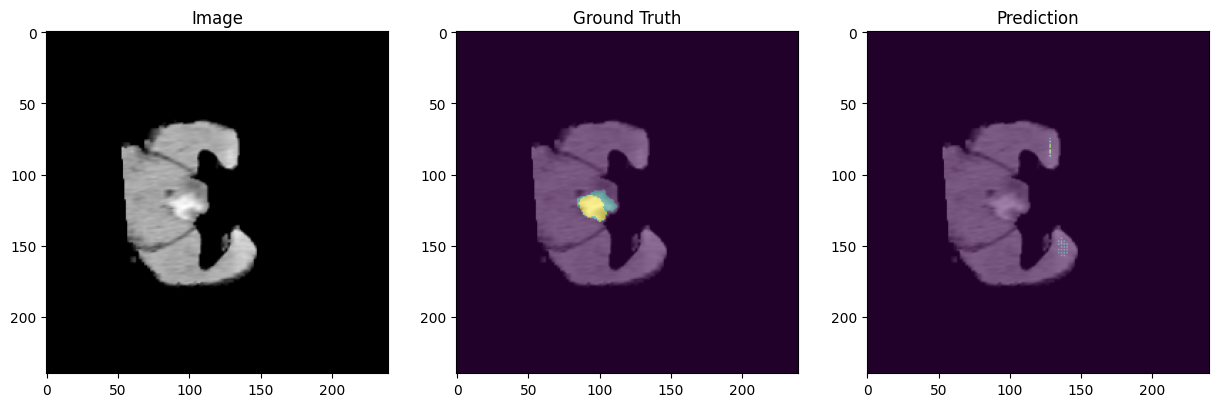

--- Slice 60 ---


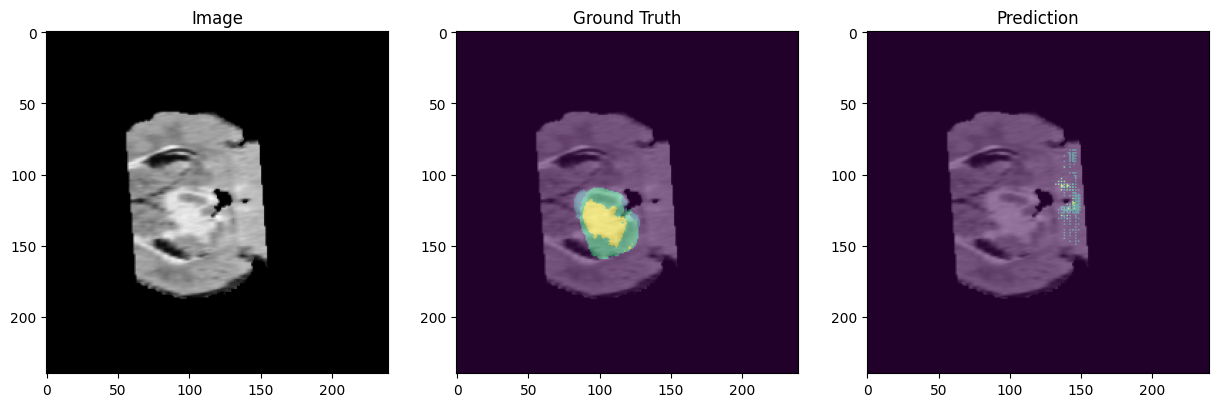

--- Slice 80 ---


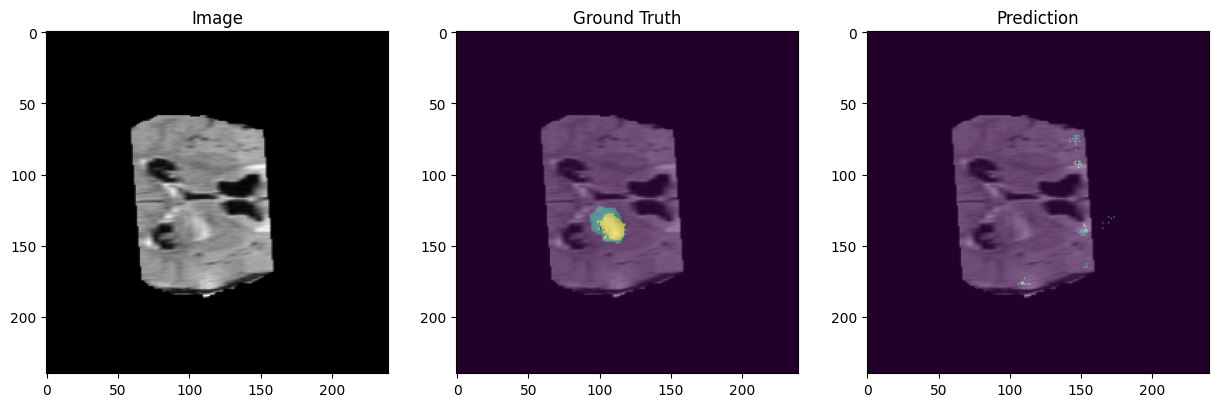

--- Slice 100 ---


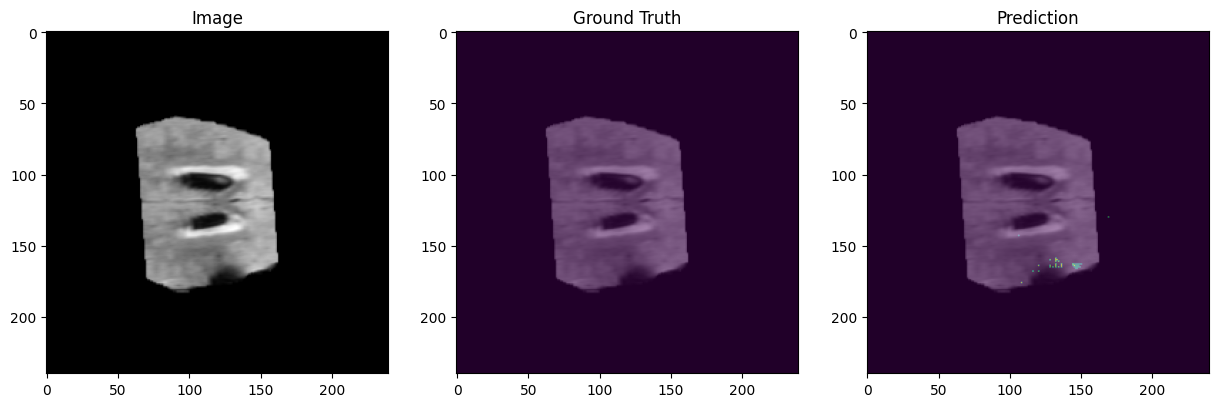


📌 Case: BRATS_022
Pred unique: [0. 1. 2. 3.]
Label unique: [0. 1. 2. 3.]
--- Slice 40 ---


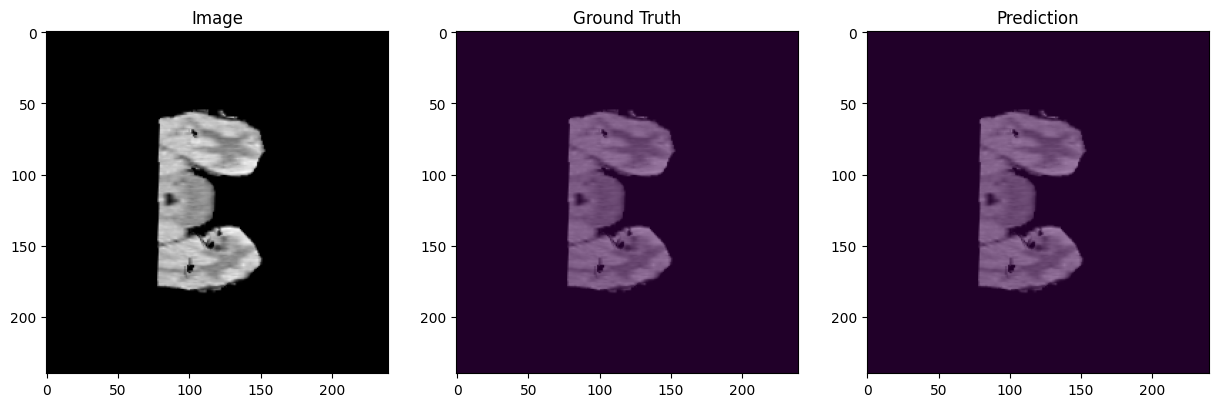

--- Slice 60 ---


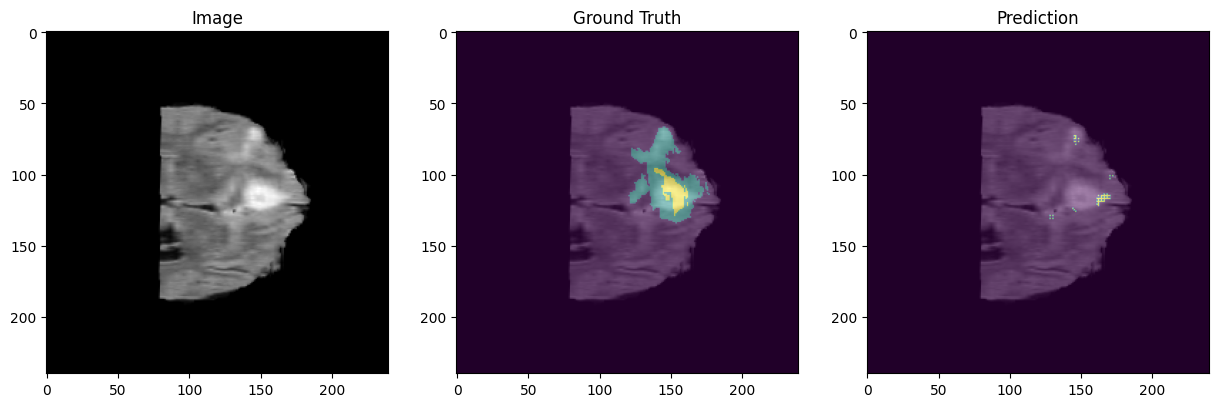

--- Slice 80 ---


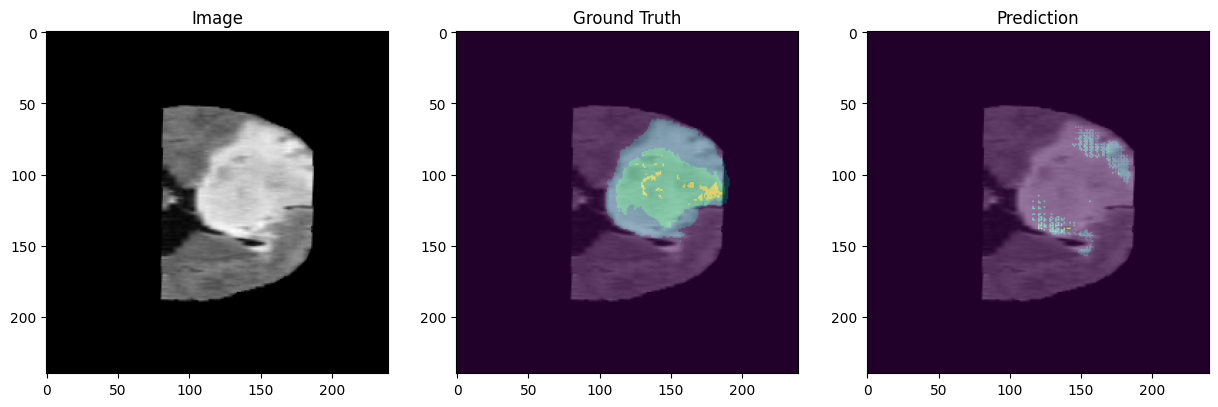

--- Slice 100 ---


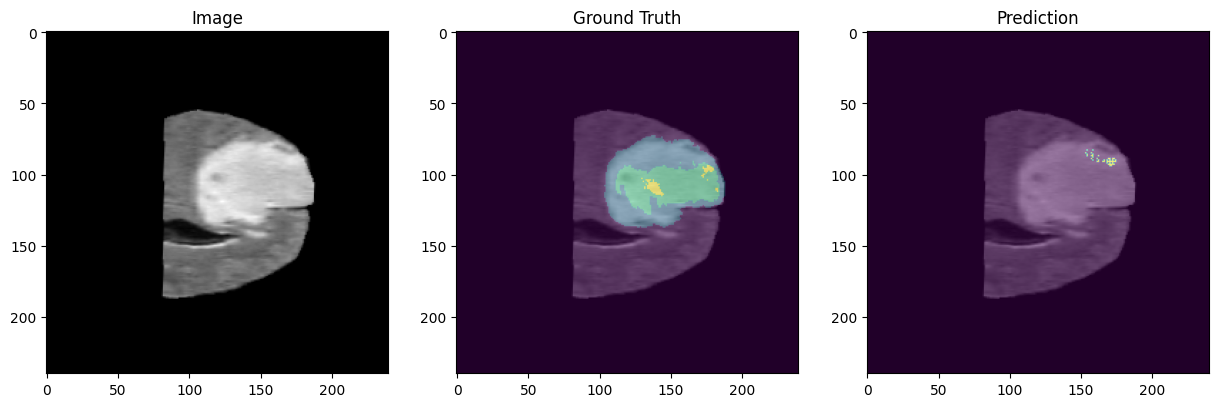


📌 Case: BRATS_023
Pred unique: [0. 1. 2. 3.]
Label unique: [0. 1. 2.]
--- Slice 40 ---


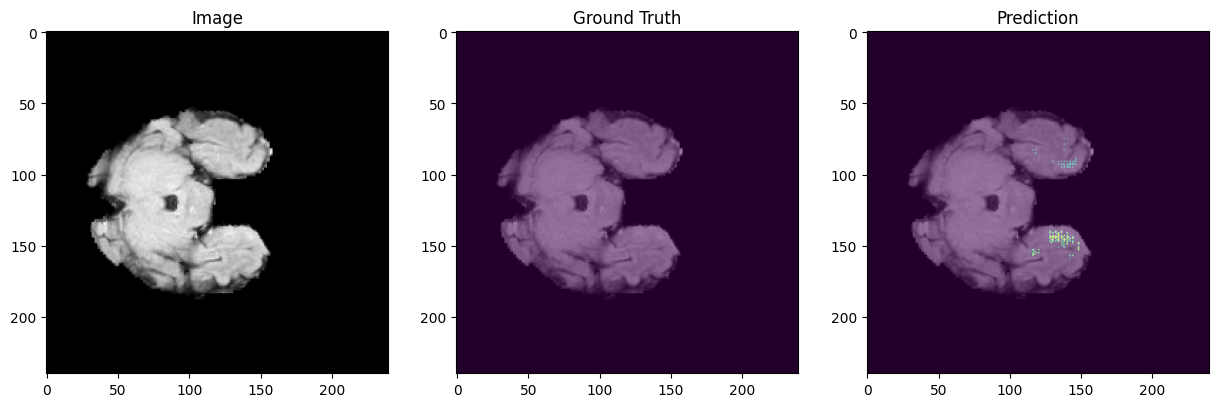

--- Slice 60 ---


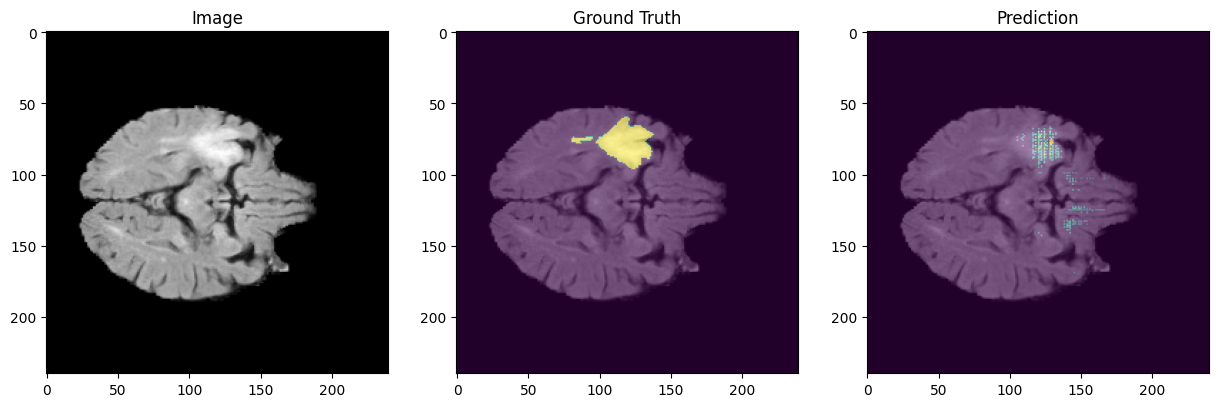

--- Slice 80 ---


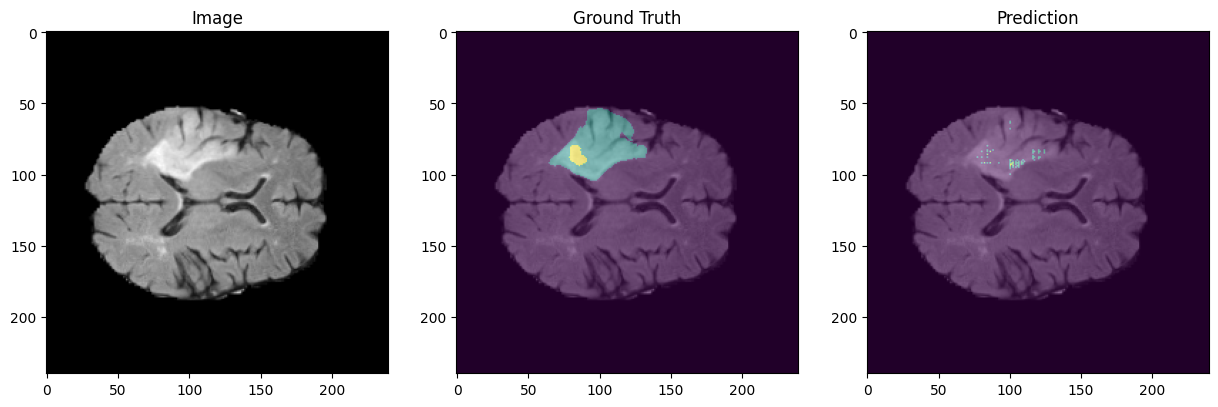

--- Slice 100 ---


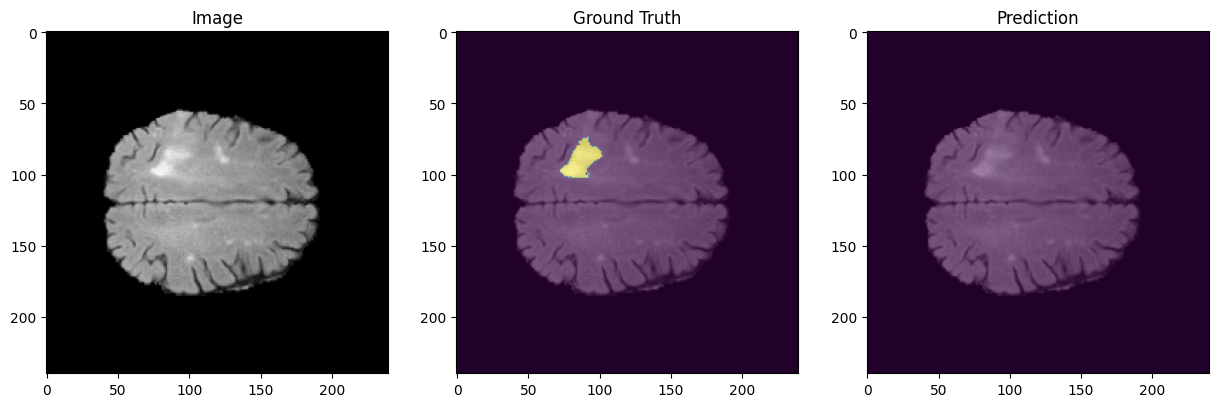

In [8]:
# 몇 개만 볼지
NUM_CASES = 3

# slice 리스트
SLICES = [40, 60, 80, 100]

for pred_path in pred_files[:NUM_CASES]:
    filename, image, label, pred = load_case(pred_path)
    
    print(f"\n📌 Case: {filename}")
    print("Pred unique:", np.unique(pred))
    print("Label unique:", np.unique(label))

    for s in SLICES:
        print(f"--- Slice {s} ---")
        show_overlay(image, label, pred, s)

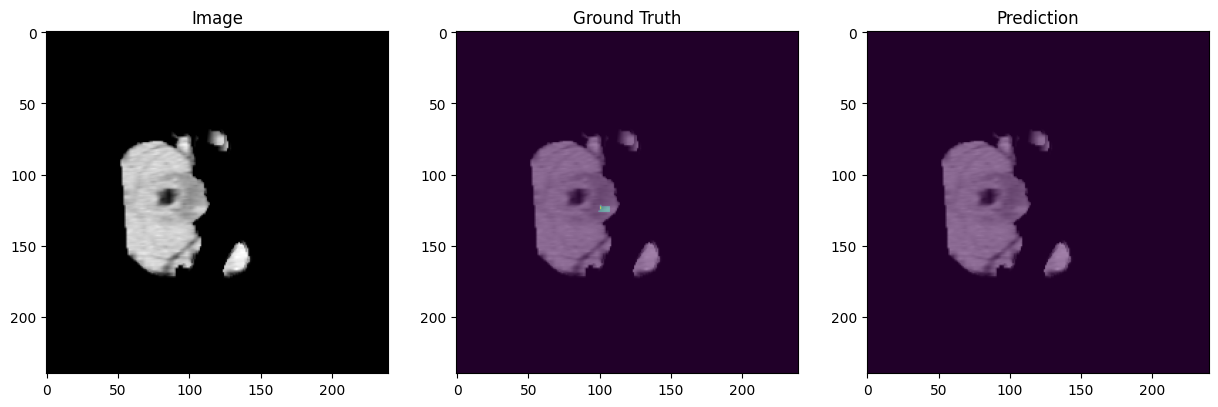

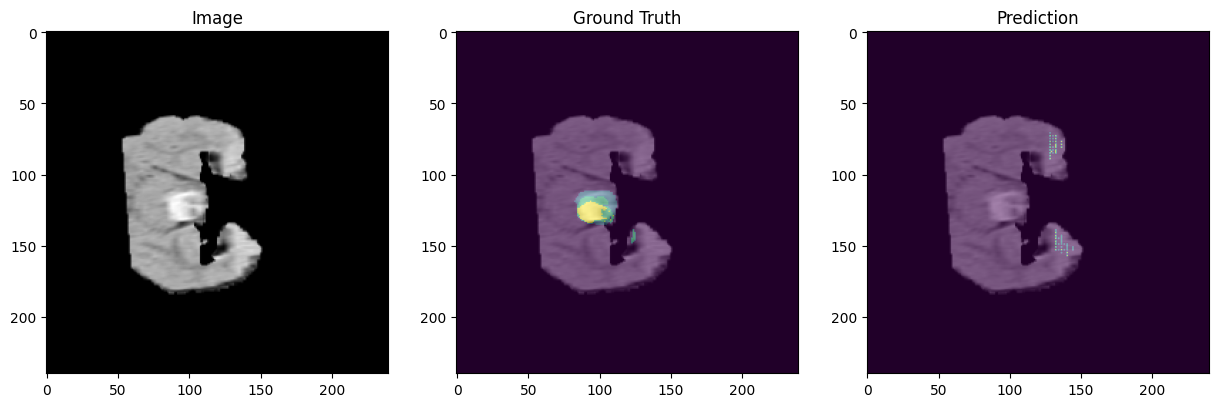

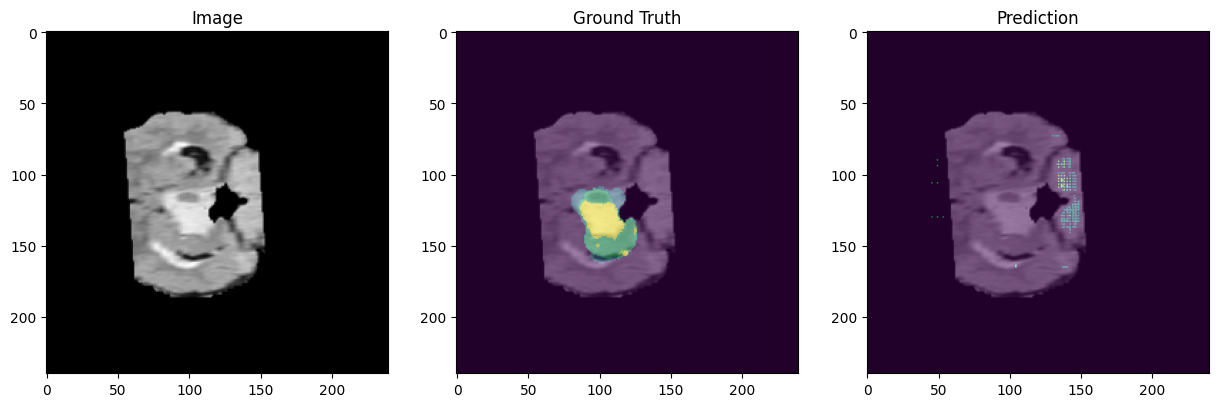

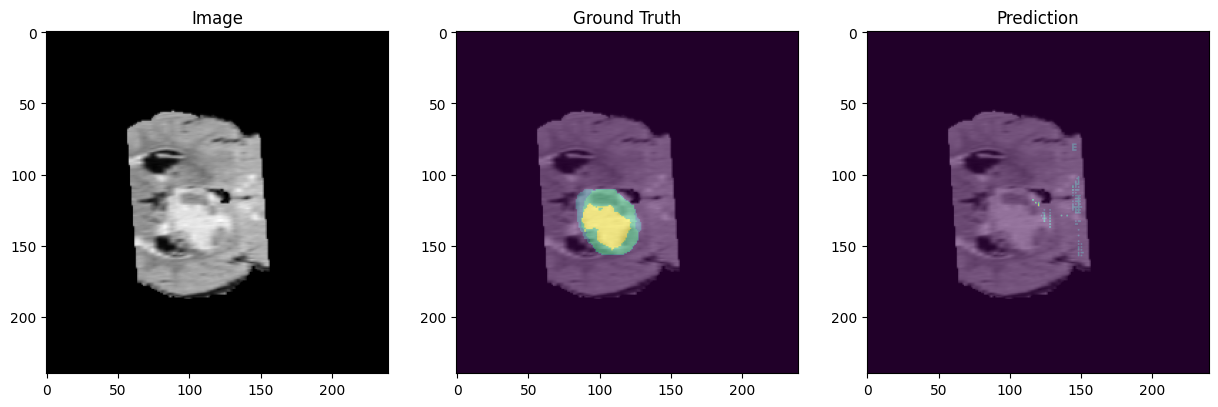

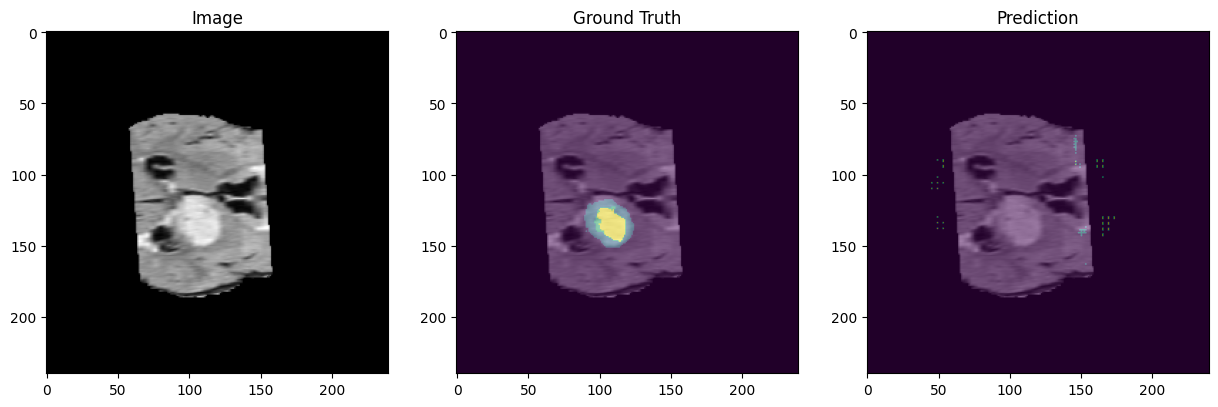

In [10]:
# tumor 있는 slice만 자동 선택
def get_tumor_slices(label):
    slices = []
    for i in range(label.shape[2]):
        if np.sum(label[:,:,i]) > 0:
            slices.append(i)
    return slices

slices = get_tumor_slices(label)
for s in slices[::10]:  # 10개 간격
    show_overlay(image, label, pred, s)

In [ ]:
##################### nnU-Net##############
# 우선 환경부터 만들기(압축풀고, images 파일명에 T1,T2 라벨이 있게)

In [5]:
# images 채널분리, 이름변경
import nibabel as nib
import numpy as np
import os

src_dir = "/mnt/c/Users/lhe09/projects/msd_brain/imagesTr"
dst_dir = "/mnt/c/Users/lhe09/projects/msd_brain_nnunet/nnUNet_raw/Dataset001_Brain/imagesTr"

os.makedirs(dst_dir, exist_ok=True)

for f in os.listdir(src_dir):
    if f.endswith(".nii.gz"):
        img = nib.load(os.path.join(src_dir, f))
        data = img.get_fdata()  # (H, W, D, 4)

        case_id = f.replace(".nii.gz", "")

        for i in range(data.shape[-1]):
            out = nib.Nifti1Image(data[..., i], img.affine)
            nib.save(out, os.path.join(dst_dir, f"{case_id}_{i:04d}.nii.gz"))

In [ ]:
# label 확인
import os

lbl_dir = "/mnt/c/Users/lhe09/projects/msd_brain_nnunet/nnUNet_raw/Dataset001_Brain/labelsTr"

for f in os.listdir(lbl_dir):
    if f.endswith(".nii.gz"):
        print(f)  # 그냥 확인용

print("labelsTr 확인 완료")

BRATS_001.nii.gz
BRATS_002.nii.gz
BRATS_003.nii.gz
BRATS_004.nii.gz
BRATS_005.nii.gz
BRATS_006.nii.gz
BRATS_007.nii.gz
BRATS_008.nii.gz
BRATS_009.nii.gz
BRATS_010.nii.gz
BRATS_011.nii.gz
BRATS_012.nii.gz
BRATS_013.nii.gz
BRATS_014.nii.gz
BRATS_015.nii.gz
BRATS_016.nii.gz
BRATS_017.nii.gz
BRATS_018.nii.gz
BRATS_019.nii.gz
BRATS_020.nii.gz
BRATS_021.nii.gz
BRATS_022.nii.gz
BRATS_023.nii.gz
BRATS_024.nii.gz
BRATS_025.nii.gz
BRATS_026.nii.gz
BRATS_027.nii.gz
BRATS_028.nii.gz
BRATS_029.nii.gz
BRATS_030.nii.gz
BRATS_031.nii.gz
BRATS_032.nii.gz
BRATS_033.nii.gz
BRATS_034.nii.gz
BRATS_035.nii.gz
BRATS_036.nii.gz
BRATS_037.nii.gz
BRATS_038.nii.gz
BRATS_039.nii.gz
BRATS_040.nii.gz
BRATS_041.nii.gz
BRATS_042.nii.gz
BRATS_043.nii.gz
BRATS_044.nii.gz
BRATS_045.nii.gz
BRATS_046.nii.gz
BRATS_047.nii.gz
BRATS_048.nii.gz
BRATS_049.nii.gz
BRATS_050.nii.gz
BRATS_051.nii.gz
BRATS_052.nii.gz
BRATS_053.nii.gz
BRATS_054.nii.gz
BRATS_055.nii.gz
BRATS_056.nii.gz
BRATS_057.nii.gz
BRATS_058.nii.gz
BRATS_059.nii.

In [ ]:
# proprecessing
# nnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity
 
# 전체를 돌리려면
#for FOLD in 0 1 2 3 4
#do
# nnUNetv2_train Dataset001_Brain 3d_fullres nnUNetTrainerV2 $FOLD
#done

# 우선 학습 상황을 맞추기 위해 100개만 돌림

# nnUNet 전처리 결과 자동설계
# nnUnet의 3단계 구조 가능 : 3D_lowres(큰이미지-> 축소해서 전체구조 먼저 학습) -> 3D fullres(원본 해상도, 디테일 학습 / 3D 모델) -> (cascade)
# Patch_size = (128, 128, 128) 
# batch size: 2
# # mediansize:[137, 169, 141]라서 128,128,128로 가능해서 lowres 안씀- Dropping 3D lowres(굳이 coarse model 필요없음)

# train
# nnUNetv2_train Dataset001_Brain 3d_fullres 0 # 3d_fullres -> 3D 모델 / 0 -> fold 0(nnUnet은 기본 5-fold)

# Mean Validation Dice:  0.7344623148960837(실제 segmentation 기반의 Dice이고 background는 제외된 Dice)


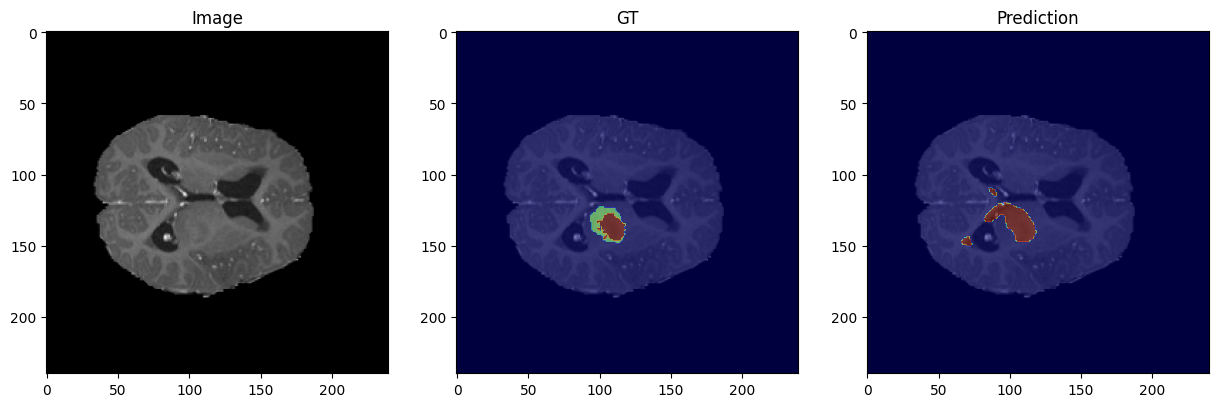

(240, 240, 155)
(240, 240, 155)
[0. 1. 2. 3.]
3.0 0.0


In [8]:
## nnUNET용 시각화
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["black", "red", "green", "blue"])

# ✅ nnUNet prediction
pred = nib.load("/mnt/c/Users/lhe09/projects/msd_brain_nnunet/nnUNet_results/Dataset001_Brain/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/BRATS_021.nii.gz").get_fdata()

# GT
label = nib.load("/mnt/c/Users/lhe09/projects/msd_brain/labelsTr/BRATS_021.nii.gz").get_fdata()

# image (4 modality)
image = nib.load("/mnt/c/Users/lhe09/projects/msd_brain/imagesTr/BRATS_021.nii.gz").get_fdata()

slice_idx = 80

plt.figure(figsize=(15,5))

# image (T1ce 추천 = channel 2)
plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image[:,:,slice_idx,2], cmap="gray")

# GT
plt.subplot(1,3,2)
plt.title("GT")
plt.imshow(image[:,:,slice_idx,2], cmap="gray")
plt.imshow(label[:,:,slice_idx], cmap="jet", alpha=0.5)

# pred
plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(image[:,:,slice_idx,2], cmap="gray")
plt.imshow(pred[:,:,slice_idx], cmap="jet", alpha=0.5)
#plt.imshow(pred[:,:,slice_idx], cmap=cmap, alpha=0.5, vmin=0, vmax=3)

plt.show()

print(pred.shape)
print(label.shape)
print(np.unique(pred))
print(pred.max(), pred.min())

In [10]:
# 클래스별 Dice 과 HD95
import glob
import numpy as np
import nibabel as nib
import torch

from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.utils import MetricReduction

# -----------------------------
# metrics
# -----------------------------
dice_metric = DiceMetric(
    include_background=True,
    reduction=MetricReduction.NONE
)

hd_metric = HausdorffDistanceMetric(
    percentile=95,
    include_background=False,
    reduction=MetricReduction.NONE,
    get_not_nans=True
)

# -----------------------------
# one-hot
# -----------------------------
def to_onehot(seg, num_classes):
    seg = torch.from_numpy(seg).long()
    return torch.nn.functional.one_hot(seg, num_classes)\
        .permute(3,0,1,2).contiguous()

# -----------------------------
# path
# -----------------------------
pred_files = sorted(glob.glob("/mnt/c/Users/lhe09/projects/msd_brain_nnunet/nnUNet_results/Dataset001_Brain/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/BRATS_021.nii.gz"))
gt_files   = sorted(glob.glob("/mnt/c/Users/lhe09/projects/msd_brain/labelsTr/BRATS_021.nii.gz"))

num_classes = 4

dice_scores = []
hd_scores = []

for pred_path, gt_path in zip(pred_files, gt_files):

    pred_nii = nib.load(pred_path).get_fdata().astype(np.int32)
    gt_nii   = nib.load(gt_path).get_fdata().astype(np.int32)

    pred = to_onehot(pred_nii, num_classes).unsqueeze(0).float()
    gt   = to_onehot(gt_nii, num_classes).unsqueeze(0).float()

    # Dice
    dice_metric(y_pred=pred, y=gt)
    dice = dice_metric.aggregate()
    dice_metric.reset()

    # HD95
    hd_metric(y_pred=pred, y=gt)
    hd, _ = hd_metric.aggregate()
    hd_metric.reset()

    print(f"\nFile: {pred_path}")
    print("Dice per class:", dice.numpy())
    print("HD95 per class:", hd.numpy())

    dice_scores.append(dice.numpy())
    hd_scores.append(hd.numpy())

# 평균
print("\n===== FINAL AVERAGE =====")
print("Dice mean:", np.mean(dice_scores, axis=0))
print("HD95 mean:", np.mean(hd_scores, axis=0))


File: /mnt/c/Users/lhe09/projects/msd_brain_nnunet/nnUNet_results/Dataset001_Brain/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/BRATS_021.nii.gz
Dice per class: [[0.9990514  0.39272332 0.6190663  0.85161644]]
HD95 per class: [[18.380684  6.164414  3.      ]]

===== FINAL AVERAGE =====
Dice mean: [[0.9990514  0.39272332 0.6190663  0.85161644]]
HD95 mean: [[18.380684  6.164414  3.      ]]


/home/lhe09/miniconda3/envs/second/lib/python3.9/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


In [ ]:
#################### DynUNet과 nnUNet의 비교 #######################
## nnUNET 
# Dice mean: [[0.9990514 0.39272332 0.6190663 0.85161644]] 
# HD95 mean: [[18.380684 6.164414 3. ]] 

## Dynunet 
# Dice mean: [[0.99835384 0.3164494 0.71868813 0.85177034]] 
# HD95 mean: [[39.127995 29.836214 52.84126]]

# 클래스 별 Dice 비슷 대략적인 위치/ 볼륨은 둘다 잘 맞춤
# Dynunet이 broundary를 많이 벗어남. outline이 크게 있음

# nnUNet의 전처리 값으로 나온 데이터를 활용하여
# Dynunet에서 batch size를 4-> 2로 수정하고, roi_size 96-> 128, lr 0.00005 -> 0.0005로 수정하는 등으로 
# Dynunet의 성능을 조금 더 올릴 수 있을 것으로 예상됨

### 결론
# 한정된 환경의 의해 AttentionUNet과 SwinUNETR은 데이터 수와 시간으로 인해 정확한 학습이 어려웠다.
# 동일 데이터에서 DynUNet과 nnUNet을 비교한 결과, Dice score는 유사했으나, nnUNet이 HD95에서 크게 우수한 성능을 보였다.
# 이는 nnUNet의 자동화된 preprocessin 및 patch-based training 전략이 boundary accuracy에 중요한 영향을 미쳤음을 시사한다.
